# Time series basics: growth, trend and seasonality

A time series is a sequence of observations ordered in time, and that order is the whole point: consecutive values are related, so the standard assumption of independent observations no longer holds. Before any model, the first steps are always the same: plot the series, find its **trend** and **seasonal** pattern, and stabilize its **variance** if needed.

This notebook covers these steps on four datasets:

1. **Electric cars in Switzerland**: comparing growth with log differences.
2. **Australian beer production**: seasonal patterns and classical decomposition.
3. **Australian electricity production**: variance stabilization with the Box-Cox transformation and STL decomposition with an evolving seasonal pattern.
4. **Global temperature anomalies**: trend extraction and checking what is left with the autocorrelation function.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.seasonal import STL, seasonal_decompose

plt.rcParams["figure.dpi"] = 100

## 1. Growth of electric cars across Swiss cantons

The dataset contains the number of registered electric passenger cars in each of the 26 Swiss cantons from 1990 to 2017.

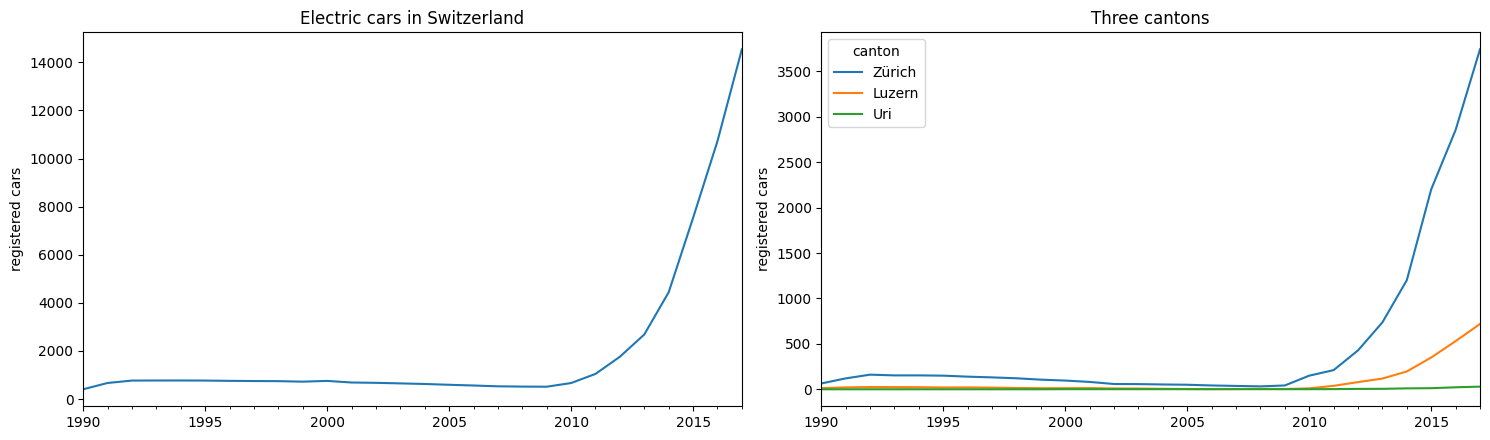

In [2]:
cars = pd.read_csv("data/electric_cars_switzerland.csv")
cars["year"] = pd.to_datetime(cars["year"], format="%Y")
wide = cars.pivot(index="year", columns="canton", values="electric_cars")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 4.5))
wide.sum(axis=1).plot(ax=ax1)
ax1.set(title="Electric cars in Switzerland", ylabel="registered cars", xlabel="")
wide[["Zürich", "Luzern", "Uri"]].plot(ax=ax2)
ax2.set(title="Three cantons", ylabel="registered cars", xlabel="")
fig.tight_layout()
plt.show()

After a small peak in the early 1990s and a slow decline afterwards (early electric models disappeared from the market), the number of electric cars took off around 2010. Comparing cantons on the raw counts is misleading, though: Zürich has a much larger population than Uri, so its curve dwarfs the others.

When the total number of vehicles is not available for normalization, a good alternative is to compare **relative growth**. For small changes, the difference of logarithms approximates the relative change:

$$\log x_t - \log x_{t-1} = \log\frac{x_t}{x_{t-1}} \approx \frac{x_t - x_{t-1}}{x_{t-1}} .$$

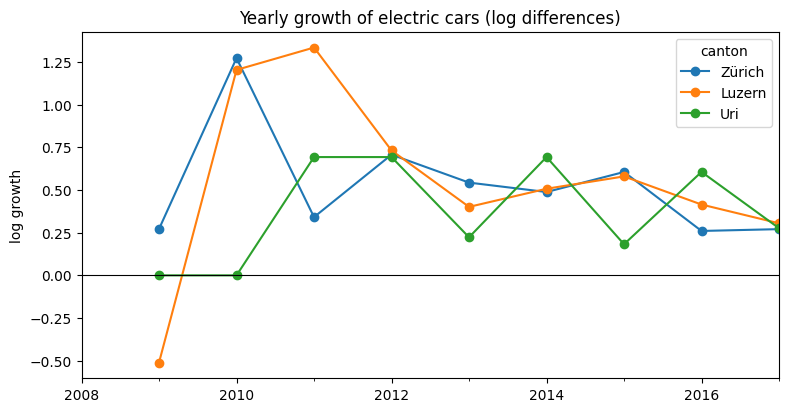

canton,Zürich,Luzern,Uri
year,,,
2009-01-01,0.27,-0.51,0.00
2010-01-01,1.27,1.20,0.00
2011-01-01,0.34,1.34,0.69
2012-01-01,0.71,0.73,0.69
2013-01-01,0.54,0.40,0.22
2014-01-01,0.49,0.51,0.69
2015-01-01,0.61,0.58,0.18
2016-01-01,0.26,0.41,0.61
2017-01-01,0.27,0.30,0.28


In [3]:
recent = wide.loc["2008":, ["Zürich", "Luzern", "Uri"]]
growth = np.log(recent).diff()

fig, ax = plt.subplots(figsize=(9, 4.5))
growth.plot(ax=ax, marker="o")
ax.axhline(0, color="black", lw=0.8)
ax.set(title="Yearly growth of electric cars (log differences)", ylabel="log growth", xlabel="")
plt.show()
growth.dropna().round(2)

On the log scale the three cantons become directly comparable. Around 2010–2011 the number of electric cars more than tripled in Zürich and Luzern (log growth above 1.2). Since then growth has stayed high everywhere, typically between +40% and +100% per year (log growth 0.35–0.7), slowing down to about +30% in 2016–2017. Small cantons like Uri have more erratic growth rates, because a handful of new cars makes a large relative difference.

## 2. Seasonality: Australian beer production

Quarterly beer production in Australia (megalitres), 1956–1994.

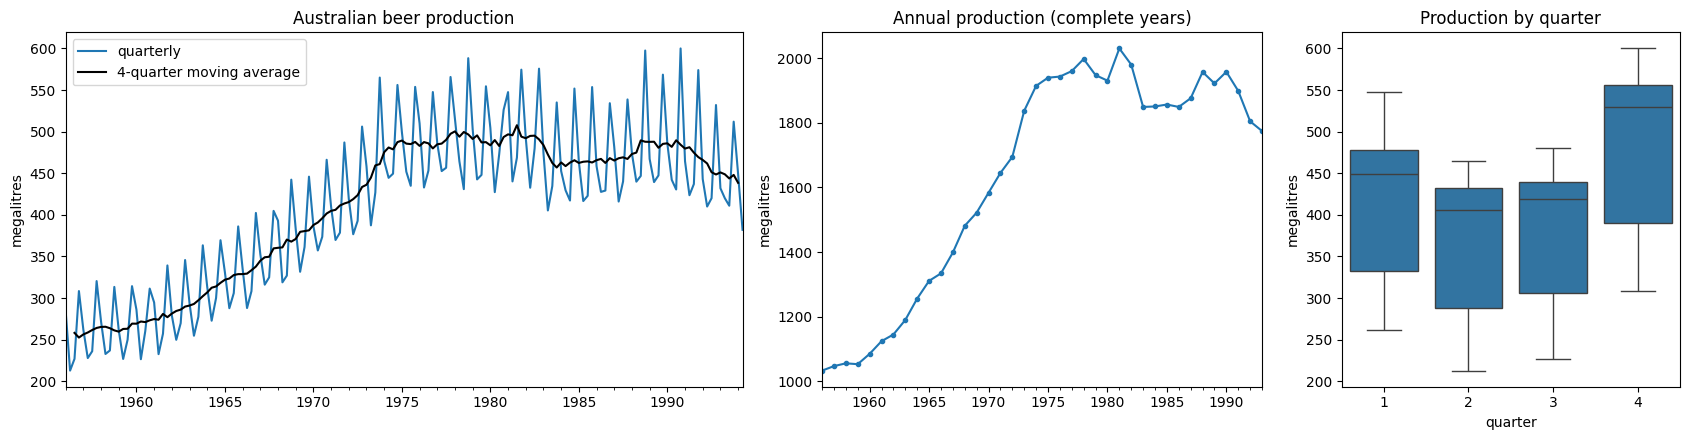

In [4]:
beer = pd.read_csv("data/australian_beer.csv")
beer.index = pd.PeriodIndex(beer["quarter"], freq="Q").to_timestamp()
beer = beer["megalitres"].asfreq("QS")

fig, axes = plt.subplots(1, 3, figsize=(17, 4.5), gridspec_kw={"width_ratios": [2, 1.3, 1]})
beer.plot(ax=axes[0], label="quarterly")
beer.rolling(4, center=True).mean().plot(ax=axes[0], color="black", label="4-quarter moving average")
axes[0].set(title="Australian beer production", ylabel="megalitres", xlabel="")
axes[0].legend()
beer.resample("YS").sum().iloc[:-1].plot(ax=axes[1], marker=".")
axes[1].set(title="Annual production (complete years)", ylabel="megalitres", xlabel="")
sns.boxplot(x=beer.index.quarter, y=beer.values, ax=axes[2])
axes[2].set(title="Production by quarter", xlabel="quarter", ylabel="megalitres")
fig.tight_layout()
plt.show()

- **Trend**: production rises steadily until the mid-1970s and then levels off. The 4-quarter moving average, which averages out one full seasonal cycle, shows this clearly.
- **Seasonality**: the fourth quarter (the Australian summer, with Christmas) has by far the highest production, the second and third (winter) the lowest.
- The size of the seasonal swings stays roughly constant over time, so an **additive** decomposition is appropriate without transforming the data:

$$x_t = \text{trend}_t + \text{seasonal}_t + \text{remainder}_t$$

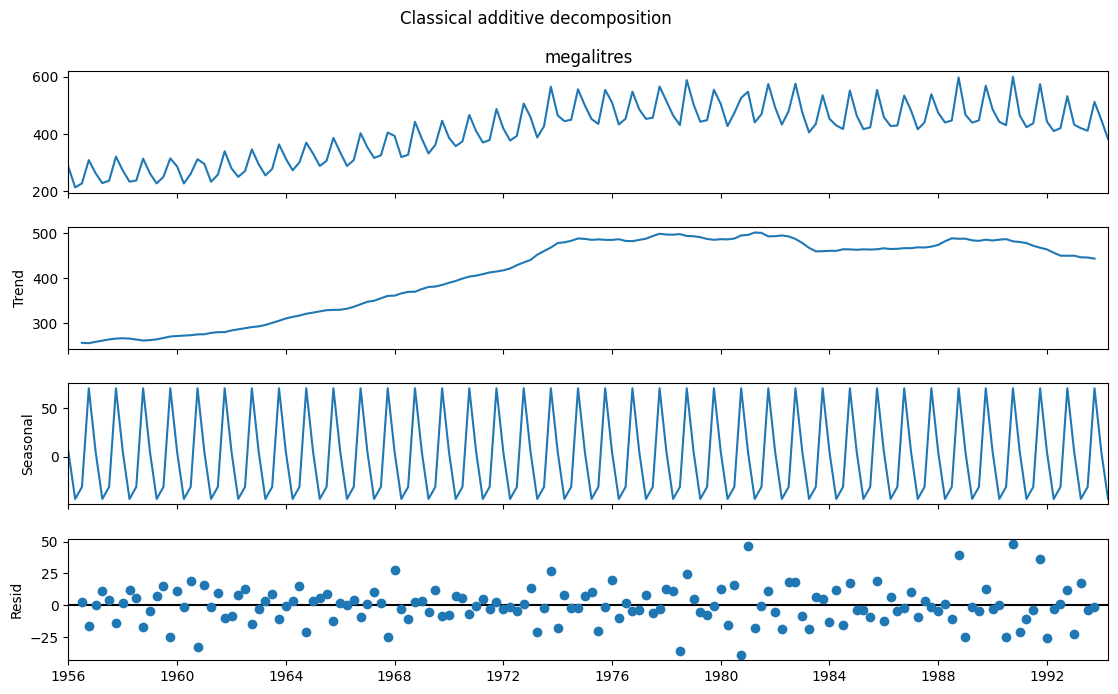

In [5]:
classical = seasonal_decompose(beer, model="additive", period=4)
fig = classical.plot()
fig.set_size_inches(12, 7)
fig.suptitle("Classical additive decomposition", y=1.01)
plt.show()

The classical decomposition estimates the trend with a moving average and assumes that the seasonal pattern is **exactly the same every year**. The remainder looks like noise, with no obvious periodic structure left, so the decomposition captures the main features of the series. Note that the moving average cannot estimate the trend for the first and last two quarters.

**STL** (Seasonal and Trend decomposition using Loess) is more flexible: it fits the trend and the seasonal component with local regression, lets the seasonal pattern change slowly over time, and also covers the ends of the series. The `seasonal` parameter controls how fast the seasonal pattern may change: small values allow fast changes, large values approach the fixed pattern of the classical method.

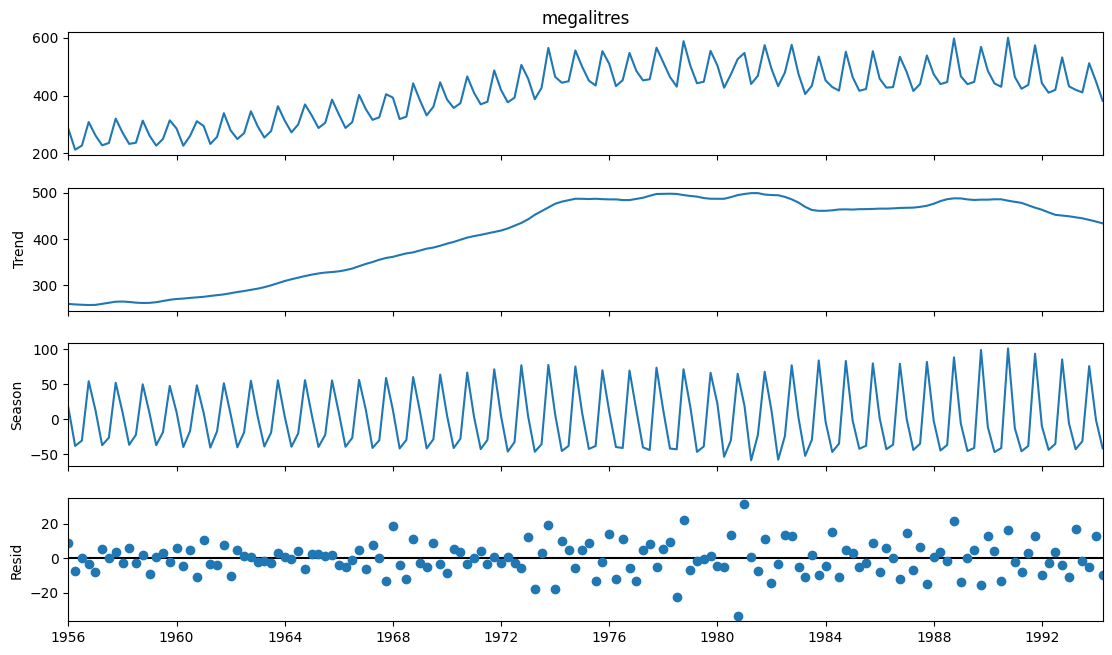

In [6]:
stl_beer = STL(beer, period=4, seasonal=7).fit()
fig = stl_beer.plot()
fig.set_size_inches(12, 7)
plt.show()

STL shows something the classical method hides: the seasonal swings **grow** over time, roughly in step with the level of production, and only shrink slightly in the last years. The trend is also estimated up to the last observation.

## 3. Stabilizing the variance: Australian electricity production

Quarterly electricity production in Australia over the same period:

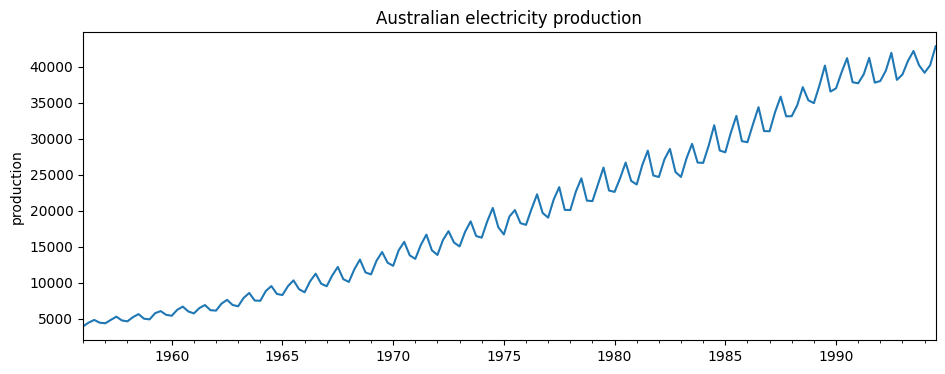

In [7]:
elec = pd.read_csv("data/australian_electricity.csv")
elec.index = pd.PeriodIndex(elec["quarter"], freq="Q").to_timestamp()
elec = elec["production"].asfreq("QS")

fig, ax = plt.subplots(figsize=(11, 4))
elec.plot(ax=ax)
ax.set(title="Australian electricity production", ylabel="production", xlabel="")
plt.show()

Here the seasonal swings grow together with the level of the series: the seasonality is **multiplicative**. An additive decomposition would leave this growing variance in the remainder. The **Box-Cox transformation**

$$y_t^{(\lambda)} = \begin{cases} \dfrac{x_t^\lambda - 1}{\lambda} & \lambda \ne 0 \\ \log x_t & \lambda = 0 \end{cases}$$

compresses large values more than small ones and can make the seasonal amplitude roughly constant. $\lambda = 1$ leaves the shape unchanged, $\lambda = 0$ is the log.

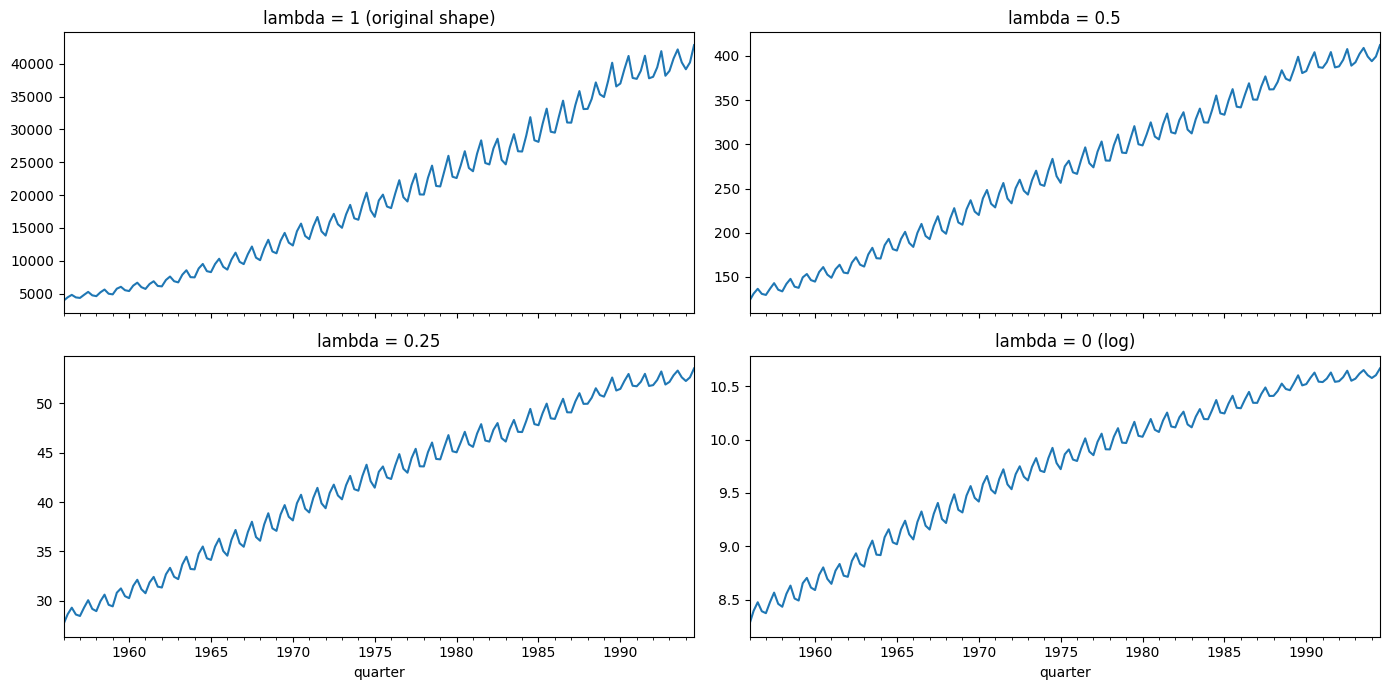

Maximum likelihood estimate of lambda: 0.38


In [8]:
def box_cox(x, lam):
    return np.log(x) if lam == 0 else (x ** lam - 1) / lam

lam_mle = stats.boxcox(elec)[1]
fig, axes = plt.subplots(2, 2, figsize=(14, 7), sharex=True)
for ax, lam in zip(axes.flat, [1, 0.5, 0.25, 0]):
    box_cox(elec, lam).plot(ax=ax)
    ax.set_title(f"lambda = {lam}" + (" (log)" if lam == 0 else " (original shape)" if lam == 1 else ""))
fig.tight_layout()
plt.show()
print(f"Maximum likelihood estimate of lambda: {lam_mle:.2f}")

With $\lambda$ between 0.25 and 0.5 the seasonal swings have about the same size at the beginning and at the end of the series. The maximum likelihood estimate (0.38) confirms this range. We use $\lambda = 0.25$ and decompose the transformed series.

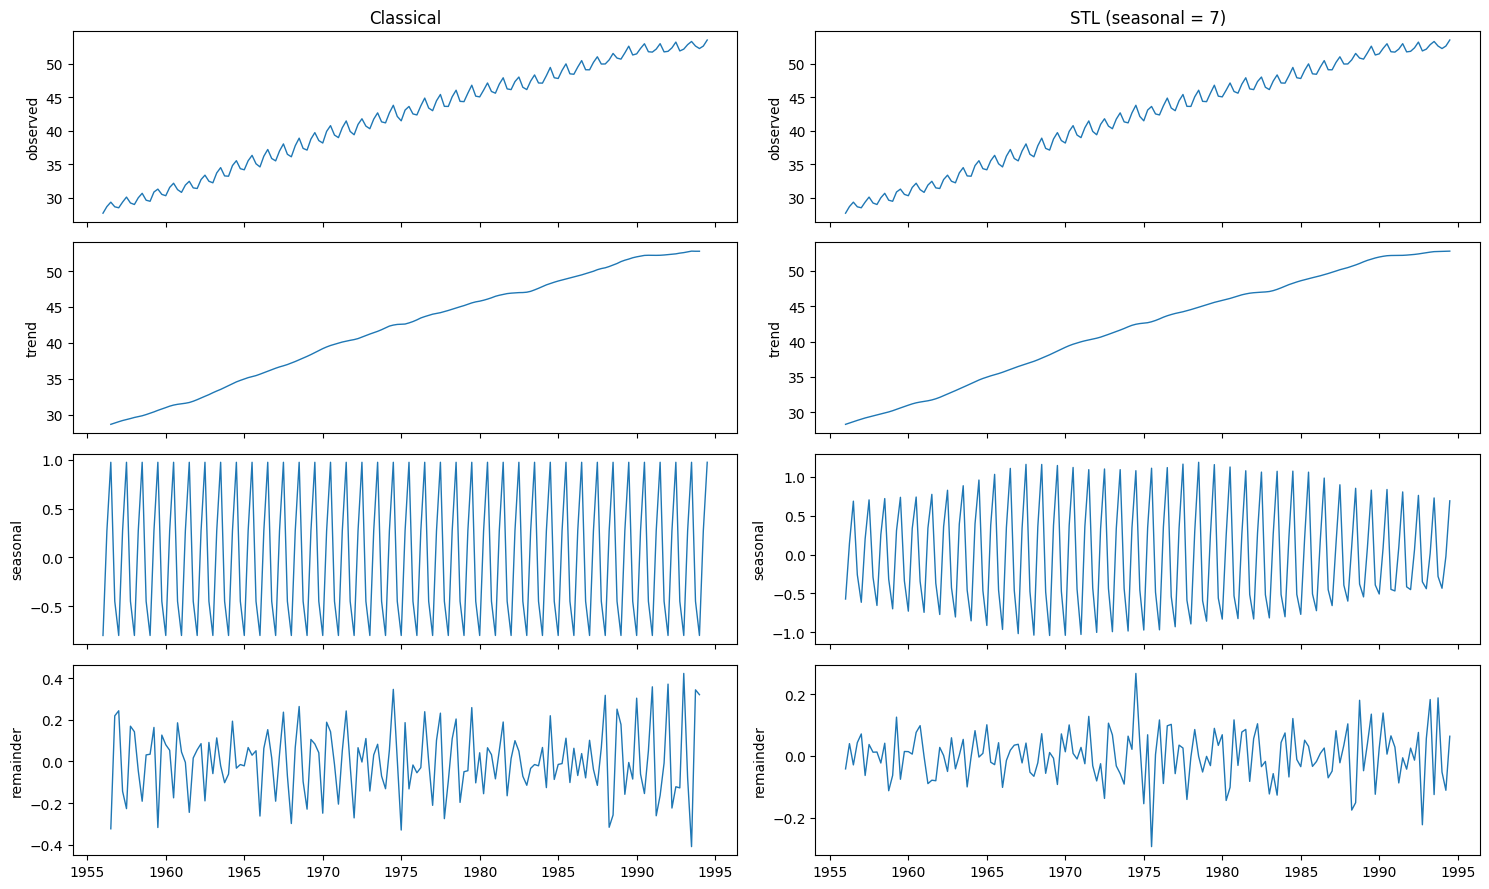

In [9]:
elec_bc = box_cox(elec, 0.25)
fig, axes = plt.subplots(4, 2, figsize=(15, 9), sharex=True)
classical = seasonal_decompose(elec_bc, model="additive", period=4)
stl_elec = STL(elec_bc, period=4, seasonal=7).fit()
for col, (name, res) in enumerate([("Classical", classical), ("STL (seasonal = 7)", stl_elec)]):
    for row, (label, comp) in enumerate([("observed", res.observed), ("trend", res.trend), ("seasonal", res.seasonal), ("remainder", res.resid)]):
        axes[row, col].plot(comp, lw=1)
        axes[row, col].set_ylabel(label)
    axes[0, col].set_title(name)
fig.tight_layout()
plt.show()

Even after the transformation the seasonal pattern is not constant: its shape changes over the decades. The classical decomposition forces one fixed pattern, so the change leaks into its remainder, which shows clear periodic structure towards the end of the series. STL lets the seasonal component evolve, and its remainder is much closer to noise. A value of about 7 for the `seasonal` parameter is a good compromise: smaller values let noise into the seasonal component, larger values make it too rigid.

## 4. Global temperature: trend and remainder

Monthly global temperature anomalies from 1850 to early 2017.

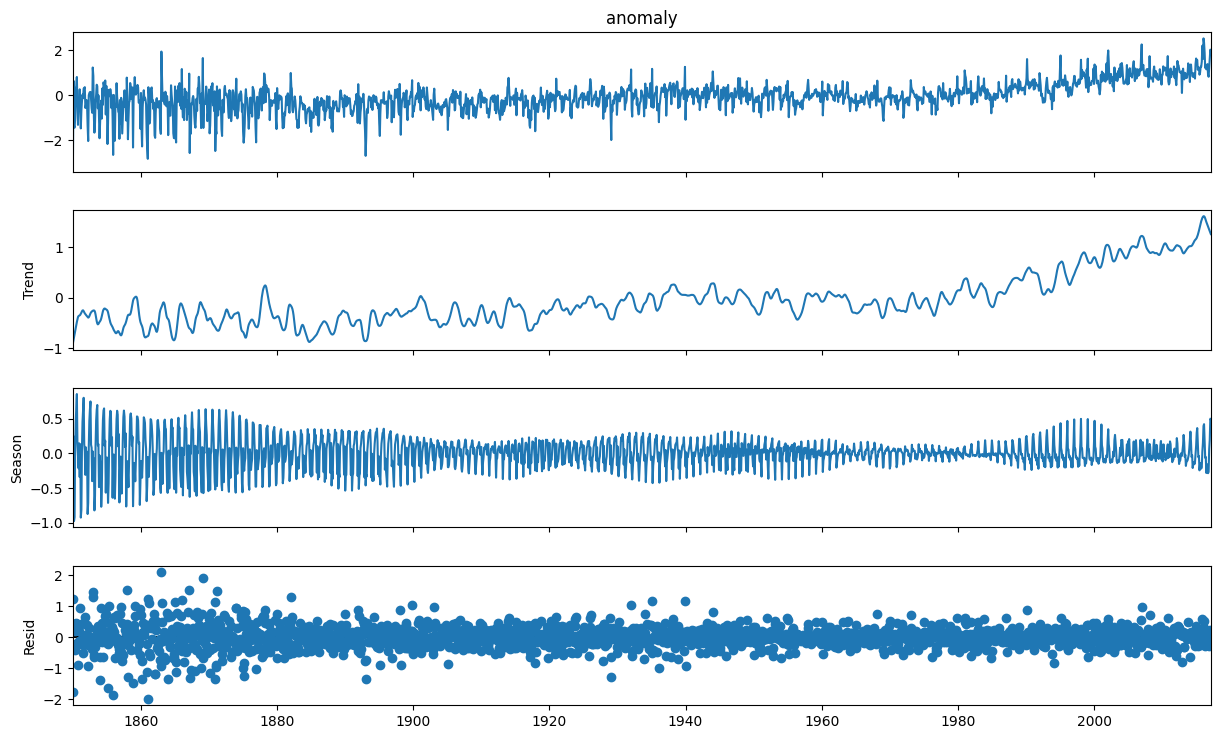

In [10]:
temp = pd.read_csv("data/global_temperature_monthly.csv", parse_dates=["date"], index_col="date")["anomaly"].asfreq("MS")
stl_temp = STL(temp, period=12, seasonal=15).fit()
fig = stl_temp.plot()
fig.set_size_inches(13, 8)
plt.show()

The trend is roughly flat until about 1910, rises until the 1940s, stays stable until the 1970s and then increases steadily, by more than one degree in 40 years. The remainder is much more volatile in the 19th century, which most likely reflects sparser and less precise measurements rather than a real change in the climate.

Is anything systematic left in the remainder? If the decomposition had captured all the structure, the remainder would be white noise: its autocorrelations would lie within the bounds $\pm 1.96 / \sqrt{n}$ that pure noise stays within 95% of the time.

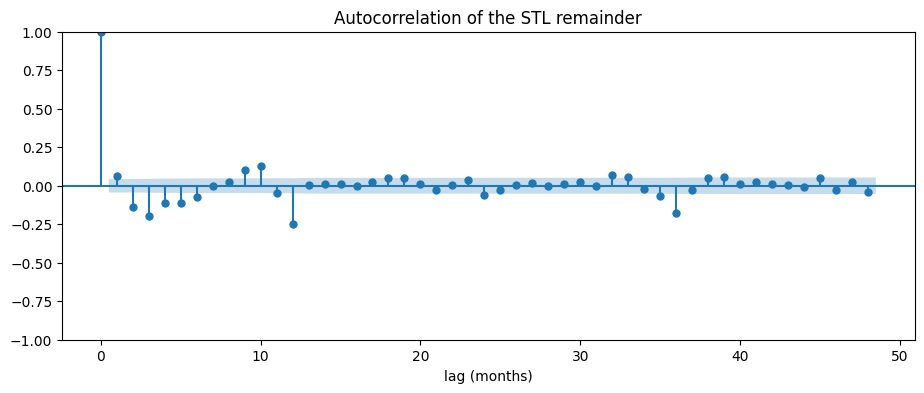

In [11]:
fig, ax = plt.subplots(figsize=(11, 4))
plot_acf(stl_temp.resid, lags=48, ax=ax, title="Autocorrelation of the STL remainder")
ax.set_xlabel("lag (months)")
plt.show()

The autocorrelations are small but several are clearly significant: negative at lags 2–6, positive at lags 9–10, and negative again at **lag 12** (and at lag 36). The negative value at lag 12 shows that the STL seasonal component slightly over-adapts: a too flexible seasonal pattern absorbs part of the noise, and the remainder compensates one year later. The remainder is therefore not white noise. It is weakly stationary (constant mean and short-range dependence), but it still has structure that a model of the dependence, such as the autoregressive models of the next notebook, can exploit.

## Summary

- **Log differences** turn absolute changes into comparable relative growth rates.
- A **moving average** over one full seasonal cycle reveals the trend; **boxplots by season** reveal the seasonal pattern.
- **Additive** decomposition requires seasonal swings of constant size. When they grow with the level, a **Box-Cox** transformation (often close to the log) stabilizes them.
- **STL** handles seasonal patterns that change over time and estimates the trend up to the ends of the series.
- The **autocorrelation of the remainder** tells whether the decomposition has captured all the structure, or whether dependence is left to model.